<hr style="border:2px solid #2196F3;">

## 🧑‍💻 Lecture 04 - Feature Engineering

<hr style="border:2px solid #2196F3;">

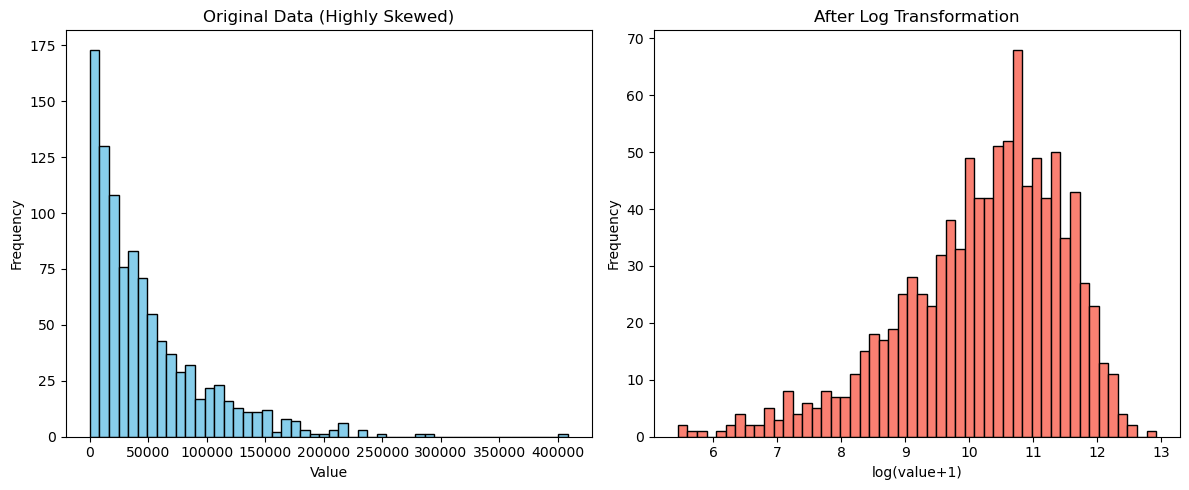

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulate highly skewed data (e.g., income distribution)
np.random.seed(42)  # for reproducibility
data = np.random.exponential(scale=50000, size=1000)  # skewed dataset

# 2. Apply log transformation (log1p handles zero safely: log(1+x))
log_data = np.log1p(data)

# 3. Plot both histograms
plt.figure(figsize=(12, 5))

# Original data
plt.subplot(1, 2, 1)
plt.hist(data, bins=50, color='skyblue', edgecolor='black')
plt.title("Original Data (Highly Skewed)")
plt.xlabel("Value")
plt.ylabel("Frequency")

# Log-transformed data
plt.subplot(1, 2, 2)
plt.hist(log_data, bins=50, color='salmon', edgecolor='black')
plt.title("After Log Transformation")
plt.xlabel("log(value+1)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

## <b>🎯Feature Scaling</b>

### 🔎Dataset: wine.csv

In [ ]:
# The loan default data set
wine_df = pd.read_csv('wine.csv')
wine_df.head()

,Type,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


<h3 style="color:#E64C17">Standardization, Normalization, log transformation</h3>

In [ ]:
# Standardization
from sklearn.preprocessing import StandardScaler

# define standard scaler
scaler = StandardScaler()
# transform data
std_wine = scaler.fit_transform(wine_df)

std_wine_df = pd.DataFrame(std_wine, columns=wine_df.columns.values.tolist())

display(std_wine_df.head())

,Type,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,-1.213944,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,-1.213944,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,-1.213944,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,-1.213944,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,-1.213944,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [ ]:
# scaling normalization
from sklearn.preprocessing import MinMaxScaler

# define min max scaler
scaler = MinMaxScaler()
# transform data
norm_wine = scaler.fit_transform(wine_df)

norm_wine_df = pd.DataFrame(norm_wine, columns=wine_df.columns.values.tolist())

display(norm_wine_df.head())

,Type,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,0.0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341
1,0.0,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642
2,0.0,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933
3,0.0,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347
4,0.0,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963


In [ ]:
# the variance of each column of wine_df
wine_df.var()

Type                                0.600679
Alcohol                             0.659062
Malic acid                          1.248015
Ash                                 0.075265
Alcalinity of ash                  11.152686
Magnesium                         203.989335
Total phenols                       0.391690
Flavanoids                          0.997719
Nonflavanoid phenols                0.015489
Proanthocyanins                     0.327595
Color intensity                     5.374449
Hue                                 0.052245
OD280/OD315 of diluted wines        0.504086
Proline                         99166.717355
dtype: float64

In [ ]:
# log transformation

# Print out the variance of the Proline column
print(wine_df['Proline'].var())

# Apply the log normalization function to the Proline column
wine_df['Proline_log'] = np.log(wine_df['Proline'])

# Check the variance of the normalized Proline column
print(wine_df['Proline_log'].var())

99166.71735542428
0.17231366191842018


## <b>🎯Feature Encoding </b>

### 🔎Dataset: hiking.json

In [ ]:
hiking = pd.read_json('hiking.json')
hiking.head()

,Prop_ID,Name,Location,Park_Name,Length,Difficulty,Other_Details,Accessible,Limited_Access,lat,lon
0,B057,Salt Marsh Nature Trail,"Enter behind the Salt Marsh Nature Center, loc...",Marine Park,0.8 miles,None,<p>The first half of this mile-long trail foll...,Y,N,NaN,NaN
1,B073,Lullwater,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,1.0 mile,Easy,Explore the Lullwater to see how nature thrive...,N,N,NaN,NaN
2,B073,Midwood,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.75 miles,Easy,Step back in time with a walk through Brooklyn...,N,N,NaN,NaN
3,B073,Peninsula,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Discover how the Peninsula has changed over th...,N,N,NaN,NaN
4,B073,Waterfall,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Trace the source of the Lake on the Waterfall ...,N,N,NaN,NaN


<h3 style="color:#E64C17">Encoding Categorical Variable -- Binary</h3>

In [ ]:
# Here I create a copy in order not to mess up with the original dataframe
hiking_enc = hiking.copy()

In [ ]:
hiking_enc['Accessible_enc'] = hiking['Accessible'].apply(lambda val: 1 if val == "Y" else 0)
print(hiking_enc[['Accessible', 'Accessible_enc']])

   Accessible  Accessible_enc
0           Y               1
1           N               0
2           N               0
3           N               0
4           N               0
5           N               0
6           N               0
7           N               0
8           N               0
9           N               0
10          N               0
11          N               0
12          N               0
13          N               0
14          N               0
15          N               0
16          N               0
17          N               0
18          N               0
19          N               0
20          N               0
21          N               0
22          N               0
23          N               0
24          N               0
25          N               0
26          N               0
27          N               0
28          N               0
29          N               0
30          N               0
31          N               0
32        

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Set up the LabelEncoder object
enc = LabelEncoder()

# Apply the encoding to the "Accessible" column
hiking_enc['Accessible_enc'] = enc.fit_transform(hiking['Accessible'])

# Compare the two columns
print(hiking_enc[['Accessible', 'Accessible_enc']].head())

  Accessible  Accessible_enc
0          Y               1
1          N               0
2          N               0
3          N               0
4          N               0


<h3 style="color:#E64C17">Encoding Categorical Variable -- one-hot encoding</h3>

### 🔎 Dataset: volunteer.csv

In [ ]:
volunteer = pd.read_csv('volunteer.csv')
volunteer.head()

,opportunity_id,content_id,vol_requests,event_time,title,hits,summary,is_priority,category_id,category_desc,...,end_date_date,status,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
0,4996,37004,50,0,Volunteers Needed For Rise Up & Stay Put! Home...,737,Building on successful events last summer and ...,NaN,NaN,NaN,...,July 30 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5008,37036,2,0,Web designer,22,Build a website for an Afghan business,NaN,1.0,Strengthening Communities,...,February 01 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5016,37143,20,0,Urban Adventures - Ice Skating at Lasker Rink,62,Please join us and the students from Mott Hall...,NaN,1.0,Strengthening Communities,...,January 29 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5022,37237,500,0,Fight global hunger and support women farmers ...,14,The Oxfam Action Corps is a group of dedicated...,NaN,1.0,Strengthening Communities,...,March 31 2012,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5055,37425,15,0,Stop 'N' Swap,31,Stop 'N' Swap reduces NYC's waste by finding n...,NaN,4.0,Environment,...,February 05 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# there are 6 categories
volunteer['category_desc'].value_counts()

Strengthening Communities    307
Helping Neighbors in Need    119
Education                     92
Health                        52
Environment                   32
Emergency Preparedness        15
Name: category_desc, dtype: int64

In [ ]:
# Transform the category_desc column
category_enc = pd.get_dummies(volunteer["category_desc"])

# Take a look at the original column and encoded columns (side-by-side)
print(volunteer['category_desc'].head(10), category_enc.head(10))

0                          NaN
1    Strengthening Communities
2    Strengthening Communities
3    Strengthening Communities
4                  Environment
5                  Environment
6    Strengthening Communities
7    Helping Neighbors in Need
8                          NaN
9                       Health
Name: category_desc, dtype: object    Education  Emergency Preparedness  Environment  Health  \
0          0                       0            0       0   
1          0                       0            0       0   
2          0                       0            0       0   
3          0                       0            0       0   
4          0                       0            1       0   
5          0                       0            1       0   
6          0                       0            0       0   
7          0                       0            0       0   
8          0                       0            0       0   
9          0                       0         

## <b>🎯Feature Creation</b>

### 🔎 Dataset: running_time
<p>This dataframe records the 5KM running time of different people over five runs (run1, run2, run3, run4, run5).</p>

In [ ]:
# initialize list of lists
data = [['Sue', 20.1,18.5,19.6,20.3,18.3], ['nick',16.5,17.1,16.9,17.6,17.3 ], ['juli',23.5,25.1,25.2,24.6,23.9]]

# Create the pandas DataFrame
running_time = pd.DataFrame(data, columns=['name', 'run1', 'run2', 'run3', 'run4', 'run5'])

# print dataframe.
running_time

,name,run1,run2,run3,run4,run5
0,Sue,20.1,18.5,19.6,20.3,18.3
1,nick,16.5,17.1,16.9,17.6,17.3
2,juli,23.5,25.1,25.2,24.6,23.9


In [ ]:
# For each name in the dataset, take the mean of their 5 run times as a newly created aggregate value

# Use .loc to create a mean column
running_time["mean"] = running_time.loc[:,'run1':'run5'].mean(axis=1)

# Take a look at the results
print(running_time)

   name  run1  run2  run3  run4  run5   mean
0   Sue  20.1  18.5  19.6  20.3  18.3  19.36
1  nick  16.5  17.1  16.9  17.6  17.3  17.08
2  juli  23.5  25.1  25.2  24.6  23.9  24.46


### 🔎 Dataset: volunteer.csv
<p>There are several columns in the volunteer dataset comprised of datetimes. Let's take a look at the start_date_date column and extract just the month to use as a feature for modeling.</p>

In [ ]:
# First, convert string column to date column
volunteer["start_date_converted"] = pd.to_datetime(volunteer['start_date_date'])

# Extract just the month from the converted column
volunteer["start_date_month"] = volunteer['start_date_converted'].dt.month

# Take a look at the converted and new month columns
print(volunteer[['start_date_date', 'start_date_converted', 'start_date_month']].head())

    start_date_date start_date_converted  start_date_month
0      July 30 2011           2011-07-30                 7
1  February 01 2011           2011-02-01                 2
2   January 29 2011           2011-01-29                 1
3  February 14 2011           2011-02-14                 2
4  February 05 2011           2011-02-05                 2
